# EDA season (2026-present) ongoing

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Read csv 

In [2]:
df=pd.read_csv('mlb_current_season.csv')
df.head(2)

,game_id,date,venue,home_team,away_team,game_type,home_score,away_score,winner,loser,...,margin,winning_pitcher,losing_pitcher,save_pitcher,top_hitter,top_hitter_team,top_hitter_line,top_pitcher,top_pitcher_team,top_pitcher_line
0,823244,2026-03-25,Oracle Park,San Francisco Giants,New York Yankees,R,0,7,New York Yankees,San Francisco Giants,...,7,Max Fried,Logan Webb,NaN,Giancarlo Stanton,New York Yankees,"2-4, 0 HR, 1 RBI",Logan Webb,San Francisco Giants,"5.0 IP, 7 K, 6 ER"
1,823649,2026-03-26,Citi Field,New York Mets,Pittsburgh Pirates,R,11,7,New York Mets,Pittsburgh Pirates,...,4,Freddy Peralta,Paul Skenes,NaN,Brandon Lowe,Pittsburgh Pirates,"2-4, 2 HR, 3 RBI",Freddy Peralta,New York Mets,"5.0 IP, 7 K, 4 ER"


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1680 entries, 0 to 1679
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   game_id           1680 non-null   int64
 1   date              1680 non-null   str  
 2   venue             1680 non-null   str  
 3   home_team         1680 non-null   str  
 4   away_team         1680 non-null   str  
 5   game_type         1680 non-null   str  
 6   home_score        1680 non-null   int64
 7   away_score        1680 non-null   int64
 8   winner            1680 non-null   str  
 9   loser             1680 non-null   str  
 10  won_by            1680 non-null   str  
 11  margin            1680 non-null   int64
 12  winning_pitcher   1673 non-null   str  
 13  losing_pitcher    1673 non-null   str  
 14  save_pitcher      862 non-null    str  
 15  top_hitter        1673 non-null   str  
 16  top_hitter_team   1673 non-null   str  
 17  top_hitter_line   1673 non-null   str  
 18 

After looking at the info we can conclude
date is sting,columns from winning_pitcher to last column have 7 null values, save_pitcher has 818 nulls
let's look at them 

In [4]:
#df[df.isna().any(axis=1)]
#df.isna().sum()
df[df.drop(columns='save_pitcher').isna().any(axis=1)]

,game_id,date,venue,home_team,away_team,game_type,home_score,away_score,winner,loser,...,margin,winning_pitcher,losing_pitcher,save_pitcher,top_hitter,top_hitter_team,top_hitter_line,top_pitcher,top_pitcher_team,top_pitcher_line
788,823543,2026-09-22,Yankee Stadium,New York Yankees,Tampa Bay Rays,R,0,0,Tampa Bay Rays,New York Yankees,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
805,824514,2026-08-17,Great American Ball Park,Cincinnati Reds,St. Louis Cardinals,R,0,0,St. Louis Cardinals,Cincinnati Reds,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
977,823539,2026-08-29,Yankee Stadium,New York Yankees,Boston Red Sox,R,0,0,Boston Red Sox,New York Yankees,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1038,824589,2026-08-20,Rate Field,Chicago White Sox,Atlanta Braves,R,0,0,Atlanta Braves,Chicago White Sox,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1083,824424,2026-09-04,Progressive Field,Cleveland Guardians,Detroit Tigers,R,0,0,Detroit Tigers,Cleveland Guardians,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1132,824911,2026-08-31,Truist Park,Atlanta Braves,San Francisco Giants,R,0,0,San Francisco Giants,Atlanta Braves,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1175,824664,2026-08-06,Wrigley Field,Chicago Cubs,Toronto Blue Jays,R,0,0,Toronto Blue Jays,Chicago Cubs,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Just look the dates of all the rows that have atleast 1 null value
The dates are in future so that is a mistake for sure. These games have not yet been played.
We can remove these rows.

In [5]:
#drop_rows=df[df.drop(columns='save_pitcher').isna().any(axis=1)]
mlb=df.dropna(subset=df.columns.drop('save_pitcher'))

In [6]:
mlb.isna().sum()

game_id               0
date                  0
venue                 0
home_team             0
away_team             0
game_type             0
home_score            0
away_score            0
winner                0
loser                 0
won_by                0
margin                0
winning_pitcher       0
losing_pitcher        0
save_pitcher        811
top_hitter            0
top_hitter_team       0
top_hitter_line       0
top_pitcher           0
top_pitcher_team      0
top_pitcher_line      0
dtype: int64

Now let's convert the date to date format

In [7]:
mlb['date']=pd.to_datetime(df['date'],format='%Y-%m-%d')
mlb.info()

<class 'pandas.DataFrame'>
Index: 1673 entries, 0 to 1679
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   game_id           1673 non-null   int64         
 1   date              1673 non-null   datetime64[us]
 2   venue             1673 non-null   str           
 3   home_team         1673 non-null   str           
 4   away_team         1673 non-null   str           
 5   game_type         1673 non-null   str           
 6   home_score        1673 non-null   int64         
 7   away_score        1673 non-null   int64         
 8   winner            1673 non-null   str           
 9   loser             1673 non-null   str           
 10  won_by            1673 non-null   str           
 11  margin            1673 non-null   int64         
 12  winning_pitcher   1673 non-null   str           
 13  losing_pitcher    1673 non-null   str           
 14  save_pitcher      862 non-null    str   

## Basic Questions

Top Teams with most won games

In [8]:
mlb['winner'].value_counts().head(3)

winner
Los Angeles Dodgers    70
Milwaukee Brewers      69
Atlanta Braves         66
Name: count, dtype: int64

Teams with most lost games

In [9]:
mlb['loser'].value_counts().head(3)

loser
Los Angeles Angels    68
New York Mets         68
Colorado Rockies      67
Name: count, dtype: int64

## Team Performance

Team with highest matches won at home

Tampa Bay Rays team perform best at home with 40 wins


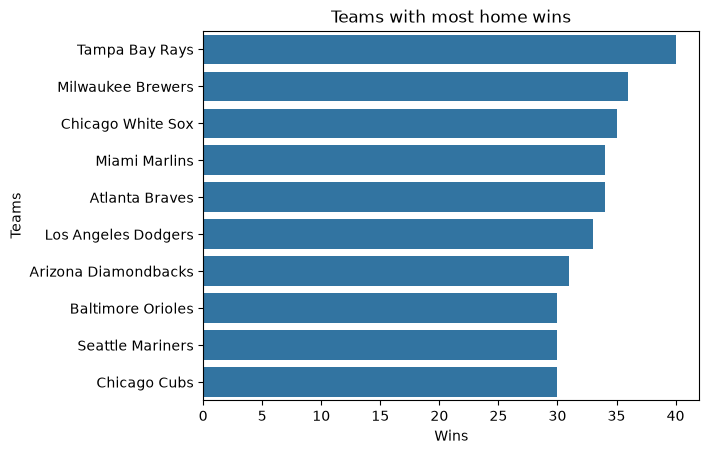

In [10]:
best_home_team=mlb[mlb['home_team']==mlb['winner']]['winner'].value_counts()
print(f'{best_home_team.index[0]} team perform best at home with {best_home_team.head(1).values[0]} wins')
sns.barplot(
    x=best_home_team.head(10).values,
    y=best_home_team.head(10).index
)
plt.title('Teams with most home wins')
plt.ylabel('Teams')
plt.xlabel('Wins')
plt.show()


Team with highest matches won at away

Los Angeles Dodgers team perform best at away with 37 wins


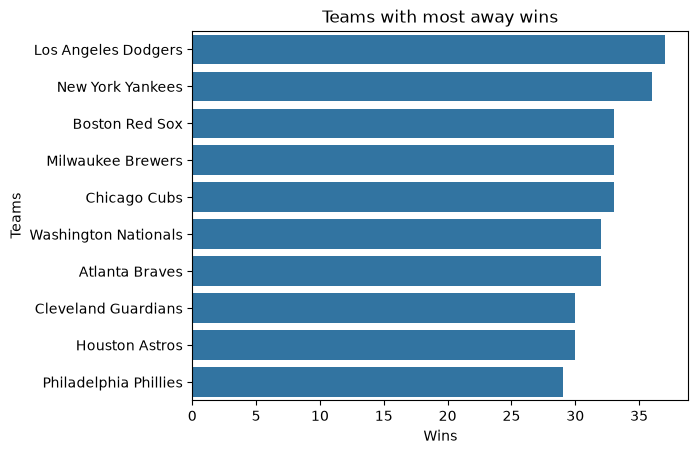

In [11]:
best_away_team=mlb[mlb['away_team']==mlb['winner']]['winner'].value_counts()
print(f'{best_away_team.index[0]} team perform best at away with {best_away_team.head(1).values[0]} wins')
sns.barplot(
    x=best_away_team.head(10).values,
    y=best_away_team.head(10).index
)
plt.title('Teams with most away wins')
plt.ylabel('Teams')
plt.xlabel('Wins')
plt.show()

Worst performing team at away

In [12]:
best_away_team=mlb[mlb['away_team']==mlb['winner']]['winner'].value_counts().tail(1)
print(f'{best_away_team.index[0]} team perform worst at away with {best_away_team.values[0]} wins')


Los Angeles Angels team perform worst at away with 18 wins


Home Field advantage,how often does the home team win?

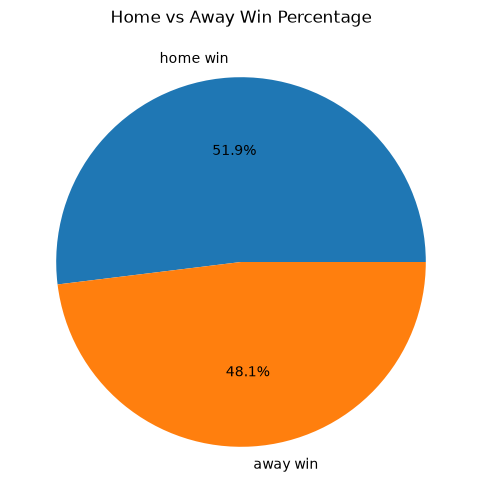

In [15]:
total_home_wins=mlb[mlb['home_team']==mlb['winner']]['winner'].count()
total_away_wins=mlb[mlb['away_team']==mlb['winner']]['winner'].count()
home_win_pct=((total_home_wins*100)/mlb.shape[0]).round(2)
plt.figure(figsize=(6,6))
plt.title('Home vs Away Win Percentage')
plt.pie([home_win_pct,away_win_pct],labels=['home win','away win'],autopct='%1.1f%%')
plt.show()

Away win percentage

In [14]:
away_win_pct=100-home_win_pct
away_win_pct

np.float64(48.06)

team with the most runs

In [16]:
total_home_score=mlb.groupby('home_team')['home_score'].sum()
total_away_score=mlb.groupby('away_team')['away_score'].sum()
total_score_by_team=(total_home_score+total_away_score).sort_values(ascending=False)
total_score_by_team.head(3)

home_team
Washington Nationals    602
Chicago Cubs            579
Los Angeles Dodgers     574
dtype: int64

Teams which allowed most runs

In [17]:
home_allowed_runs = mlb[['home_team', 'away_score']].rename(
    columns={'home_team': 'team', 'away_score': 'runs_allowed'}
)

away_allowed_runs = mlb[['away_team', 'home_score']].rename(
    columns={'away_team': 'team', 'home_score': 'runs_allowed'}
)

allowed = pd.concat([home_allowed_runs, away_allowed_runs], ignore_index=True)

most_runs_allowed = (
    allowed.groupby('team')['runs_allowed']
    .sum()
    .sort_values(ascending=False)
)
most_runs_allowed.head(3)

team
Colorado Rockies        631
Athletics               622
Washington Nationals    579
Name: runs_allowed, dtype: int64

Average margin of victory

In [18]:
mlb['score_diff']=abs(mlb['home_score']-mlb['away_score'])
avg_margin_victory=mlb['score_diff'].mean().round(2)
avg_margin_victory


np.float64(3.61)

Average runs scored by each team.

In [19]:
home=mlb[['home_team','home_score']].rename(columns={'home_team':'team','home_score':'runs'})
away=mlb[['away_team','away_score']].rename(columns={'away_team':'team','away_score':'runs'})
runs=pd.concat([home,away],ignore_index=True)
avg_runs=runs.groupby('team')['runs'].mean().sort_values(ascending=False)
avg_runs.head()

team
Washington Nationals    5.423423
Los Angeles Dodgers     5.171171
Chicago Cubs            5.169643
Milwaukee Brewers       5.035714
Pittsburgh Pirates      5.017544
Name: runs, dtype: float64

Average home vs away score

average home runs are 4.49 and avg away runs are 4.47


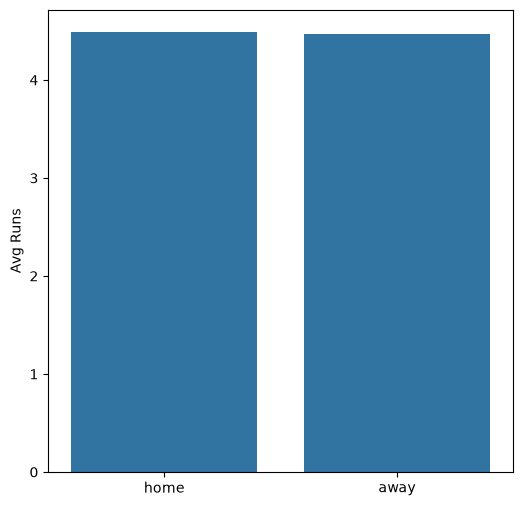

In [20]:
avg_home_runs=home['runs'].mean().round(2)
avg_away_runs=away['runs'].mean().round(2)
print(f'average home runs are {avg_home_runs} and avg away runs are {avg_away_runs}')
plt.figure(figsize=(6,6))
sns.barplot(x=['home','away'],y=[avg_home_runs,avg_away_runs])
plt.ylabel('Avg Runs')
plt.show()

Highest Scoring Game

In [21]:
higest_scoring_home_game=mlb.loc[mlb['home_score'].idxmax()]
higest_scoring_away_game=mlb.loc[mlb['away_score'].idxmax()]


Print out the highest scoring games found above

In [22]:
print(f"Highest scoring HOME game: {higest_scoring_home_game['home_team']} scored {higest_scoring_home_game['home_score']} runs vs {higest_scoring_home_game['away_team']} on {higest_scoring_home_game['date'].date()}")
print(f"Highest scoring AWAY game: {higest_scoring_away_game['away_team']} scored {higest_scoring_away_game['away_score']} runs vs {higest_scoring_away_game['home_team']} on {higest_scoring_away_game['date'].date()}")

Highest scoring HOME game: Chicago Cubs scored 23 runs vs San Diego Padres on 2026-07-01
Highest scoring AWAY game: Colorado Rockies scored 23 runs vs Athletics on 2026-06-14


Lowest Scoring Game

In [23]:
lowest_scoring_home_game=mlb.loc[mlb['home_score'].idxmin()]
lowest_scoring_away_game=mlb.loc[mlb['away_score'].idxmin()]
print(f"Lowest scoring HOME game: {lowest_scoring_home_game['home_team']} scored {lowest_scoring_home_game['home_score']} runs vs {lowest_scoring_home_game['away_team']} on {lowest_scoring_home_game['date'].date()}")
print(f"Lowest scoring AWAY game: {lowest_scoring_away_game['away_team']} scored {lowest_scoring_away_game['away_score']} runs vs {lowest_scoring_away_game['home_team']} on {lowest_scoring_away_game['date'].date()}")

Lowest scoring HOME game: San Francisco Giants scored 0 runs vs New York Yankees on 2026-03-25
Lowest scoring AWAY game: Kansas City Royals scored 0 runs vs Atlanta Braves on 2026-03-27


Total Runs feature, and distribution of runs scored per game

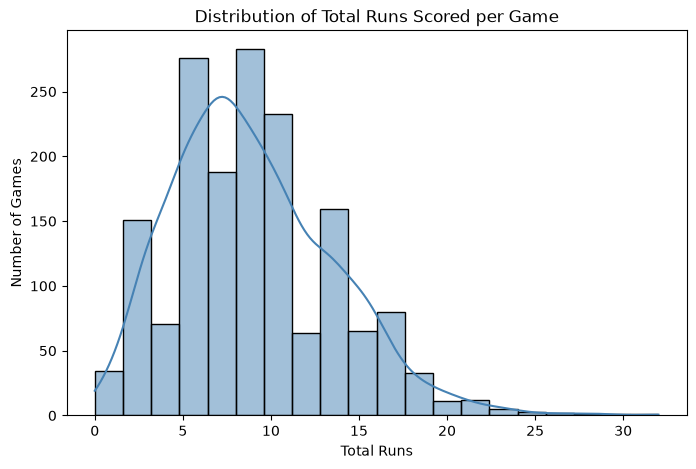

In [24]:
mlb['total_runs']=mlb['home_score']+mlb['away_score']

plt.figure(figsize=(8,5))
sns.histplot(mlb['total_runs'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Total Runs Scored per Game')
plt.xlabel('Total Runs')
plt.ylabel('Number of Games')
plt.show()

Average and Median runs scored per game

In [25]:
avg_runs_per_game=mlb['total_runs'].mean().round(2)
median_runs_per_game=mlb['total_runs'].median()
print(f'Average runs per game: {avg_runs_per_game}')
print(f'Median runs per game: {median_runs_per_game}')

Average runs per game: 8.96
Median runs per game: 8.0


Boxplot of Total Runs (helps spot outlier / blowout-style high scoring games)

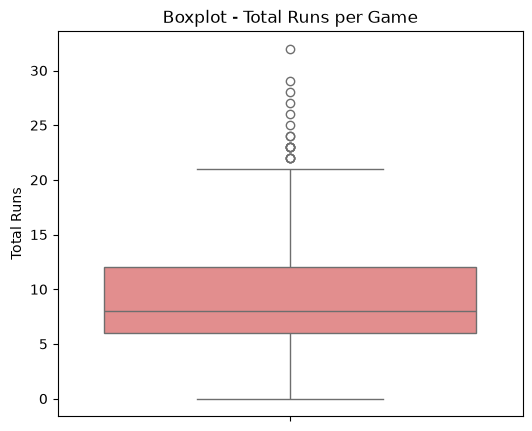

In [26]:
plt.figure(figsize=(6,5))
sns.boxplot(y=mlb['total_runs'], color='lightcoral')
plt.title('Boxplot - Total Runs per Game')
plt.ylabel('Total Runs')
plt.show()

## Feature Engineering

Extracting date parts and creating :
- month, day, weekday
- home_team_won (bool)
- close_game (margin <= 2), blowout (margin >= 6)
- run_differential (signed, home - away), one_run_game, shutout_game, double_digit_runs


In [27]:
mlb['month']=mlb['date'].dt.month
mlb['day']=mlb['date'].dt.day
mlb['weekday']=mlb['date'].dt.day_name()

mlb['home_team_won']=mlb['home_team']==mlb['winner']
mlb['close_game']=mlb['margin']<=2
mlb['blowout']=mlb['margin']>=6

mlb['run_differential']=mlb['home_score']-mlb['away_score']
mlb['home_win']=mlb['home_team_won'].astype(int)
mlb['one_run_game']=mlb['margin']==1
mlb['shutout_game']=(mlb['home_score']==0)|(mlb['away_score']==0)
mlb['double_digit_runs']=mlb['total_runs']>=10

mlb[['date','month','day','weekday','total_runs','home_team_won','close_game','blowout','run_differential','one_run_game','shutout_game','double_digit_runs']].head()

,date,month,day,weekday,total_runs,home_team_won,close_game,blowout,run_differential,one_run_game,shutout_game,double_digit_runs
0,2026-03-25,3,25,Wednesday,7,False,False,True,-7,False,True,False
1,2026-03-26,3,26,Thursday,18,True,False,False,4,False,False,True
2,2026-03-26,3,26,Thursday,16,True,False,True,12,False,False,True
3,2026-03-26,3,26,Thursday,14,False,False,True,-6,False,False,True
4,2026-03-26,3,26,Thursday,3,True,True,False,1,True,False,False


Which month had the highest scoring games?

Highest scoring month: 6 with avg 9.36 runs/game


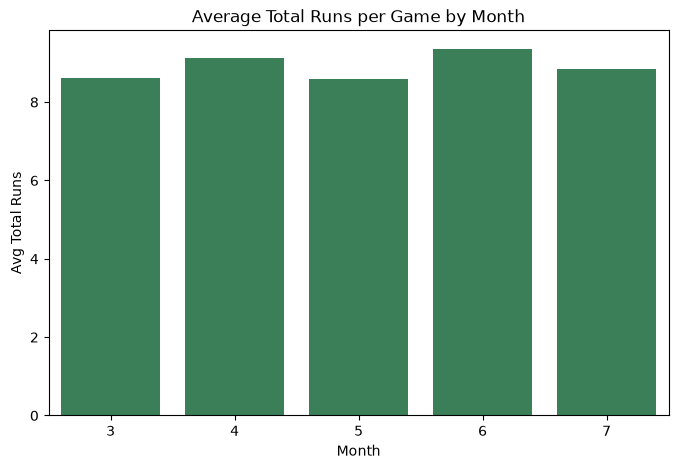

In [28]:
month_scoring=mlb.groupby('month')['total_runs'].mean().round(2)
print(f'Highest scoring month: {month_scoring.idxmax()} with avg {month_scoring.max()} runs/game')

plt.figure(figsize=(8,5))
sns.barplot(x=month_scoring.index, y=month_scoring.values, color='seagreen')
plt.title('Average Total Runs per Game by Month')
plt.xlabel('Month')
plt.ylabel('Avg Total Runs')
plt.show()

## Time Series

Games played each month

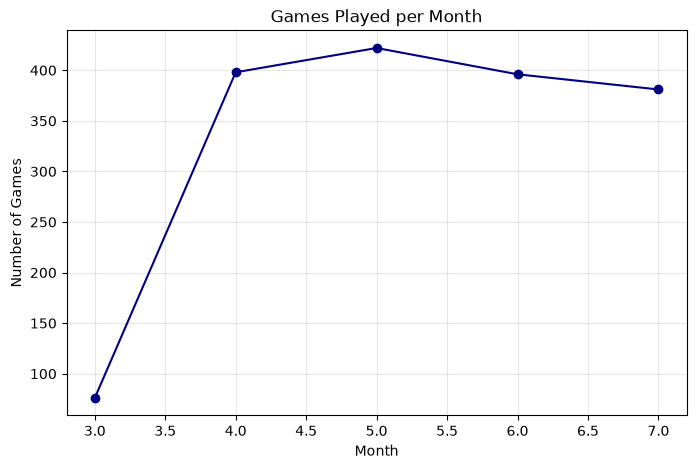

In [29]:
games_per_month=mlb.groupby('month')['game_id'].count()

plt.figure(figsize=(8,5))
plt.plot(games_per_month.index, games_per_month.values, marker='o', color='navy')
plt.title('Games Played per Month')
plt.xlabel('Month')
plt.ylabel('Number of Games')
plt.grid(alpha=0.3)
plt.show()

Runs scored each month

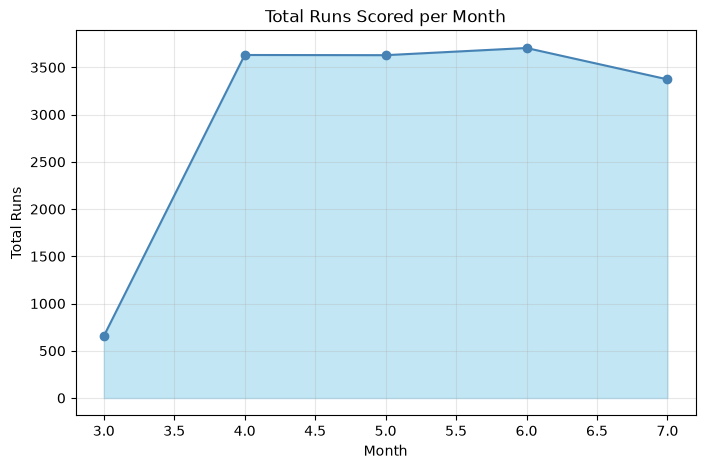

In [30]:
runs_per_month=mlb.groupby('month')['total_runs'].sum()

plt.figure(figsize=(8,5))
plt.fill_between(runs_per_month.index, runs_per_month.values, color='skyblue', alpha=0.5)
plt.plot(runs_per_month.index, runs_per_month.values, marker='o', color='steelblue')
plt.title('Total Runs Scored per Month')
plt.xlabel('Month')
plt.ylabel('Total Runs')
plt.grid(alpha=0.3)
plt.show()

Average margin by month

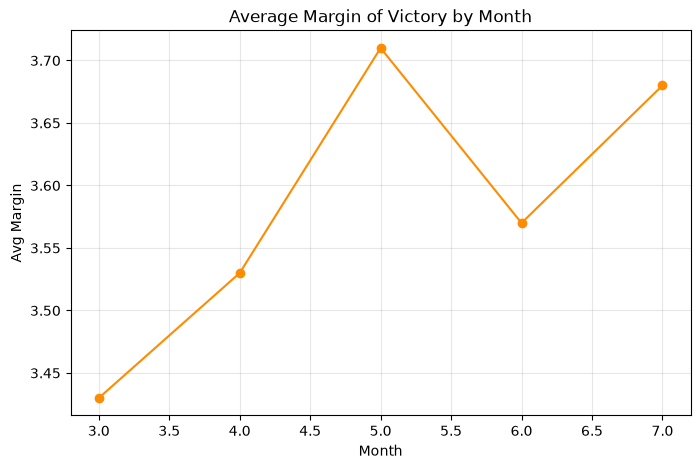

In [31]:
margin_by_month=mlb.groupby('month')['margin'].mean().round(2)

plt.figure(figsize=(8,5))
plt.plot(margin_by_month.index, margin_by_month.values, marker='o', color='darkorange')
plt.title('Average Margin of Victory by Month')
plt.xlabel('Month')
plt.ylabel('Avg Margin')
plt.grid(alpha=0.3)
plt.show()

Home win percentage over time (by month)

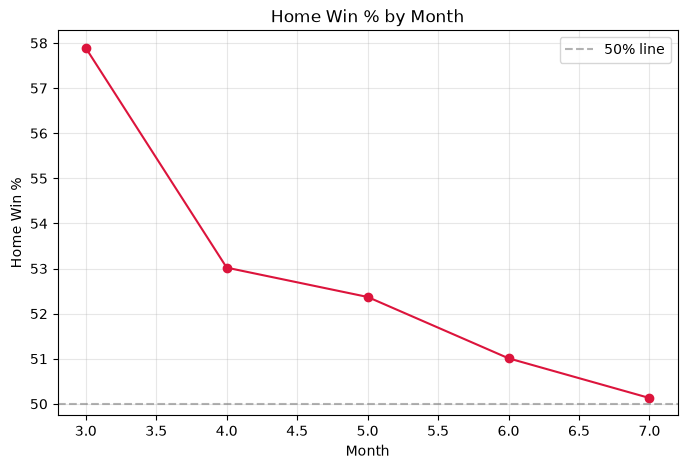

In [32]:
home_win_pct_by_month=mlb.groupby('month')['home_win'].mean().mul(100).round(2)

plt.figure(figsize=(8,5))
plt.plot(home_win_pct_by_month.index, home_win_pct_by_month.values, marker='o', color='crimson')
plt.axhline(50, color='gray', linestyle='--', alpha=0.6, label='50% line')
plt.title('Home Win % by Month')
plt.xlabel('Month')
plt.ylabel('Home Win %')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Team Comparisons

Which teams win the most close games (margin <= 2)?

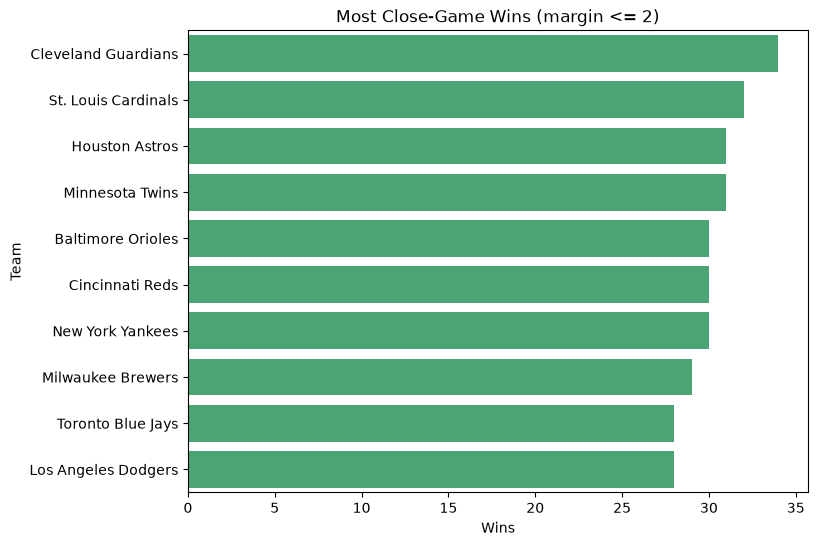

In [33]:
close_wins=mlb[mlb['close_game']]['winner'].value_counts().head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=close_wins.values, y=close_wins.index, color='mediumseagreen')
plt.title('Most Close-Game Wins (margin <= 2)')
plt.xlabel('Wins')
plt.ylabel('Team')
plt.show()

Which teams lose the most close games (margin <= 2)?

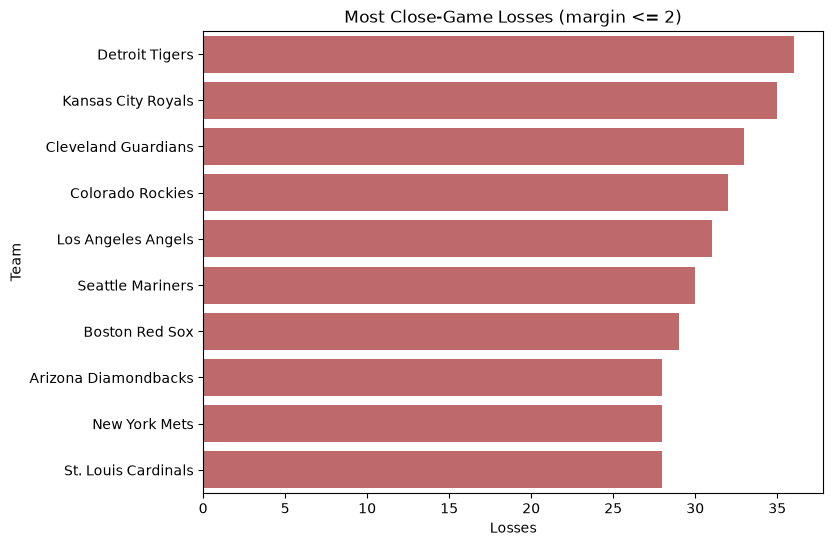

In [34]:
close_losses=mlb[mlb['close_game']]['loser'].value_counts().head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=close_losses.values, y=close_losses.index, color='indianred')
plt.title('Most Close-Game Losses (margin <= 2)')
plt.xlabel('Losses')
plt.ylabel('Team')
plt.show()

Which teams dominate opponents most (highest average margin when winning)?

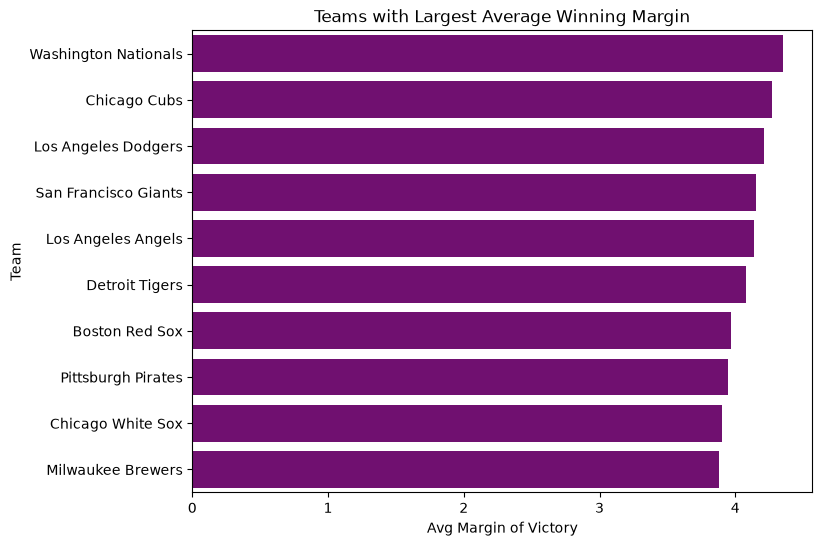

In [35]:
dominant_teams=mlb.groupby('winner')['margin'].mean().sort_values(ascending=False).head(10).round(2)

plt.figure(figsize=(8,6))
sns.barplot(x=dominant_teams.values, y=dominant_teams.index, color='purple')
plt.title('Teams with Largest Average Winning Margin')
plt.xlabel('Avg Margin of Victory')
plt.ylabel('Team')
plt.show()

Offense vs Defense heatmap (avg runs scored vs avg runs allowed by team)

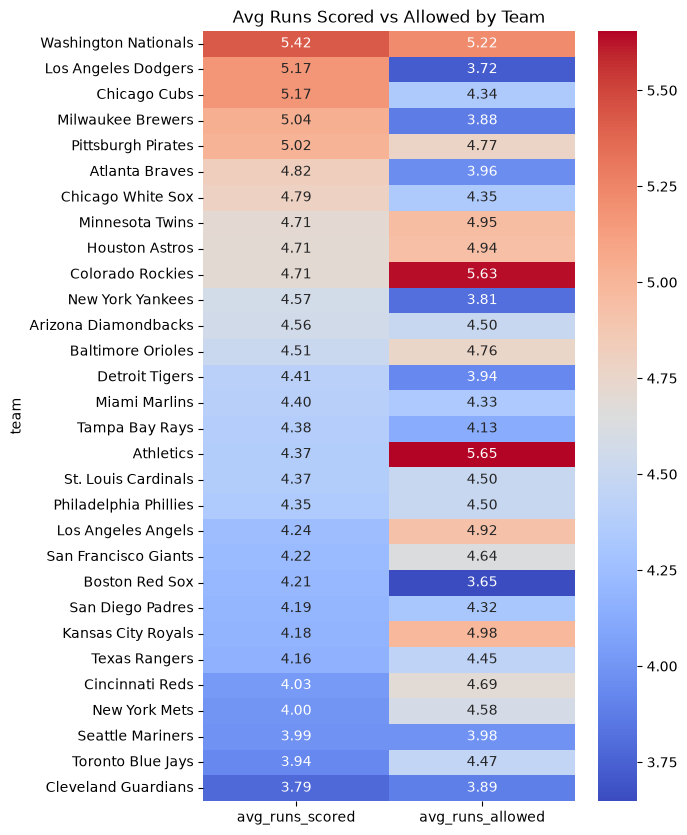

In [41]:
avg_allowed_runs=allowed.groupby('team')['runs_allowed'].mean()

offense_defense=pd.DataFrame({
    'avg_runs_scored':avg_runs,
    'avg_runs_allowed':avg_allowed_runs
}).dropna()

plt.figure(figsize=(6,10))
sns.heatmap(offense_defense.sort_values('avg_runs_scored', ascending=False), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Avg Runs Scored vs Allowed by Team')
plt.show()

##  Player Analysis

### Hitters

Most 'Top Hitter' awards

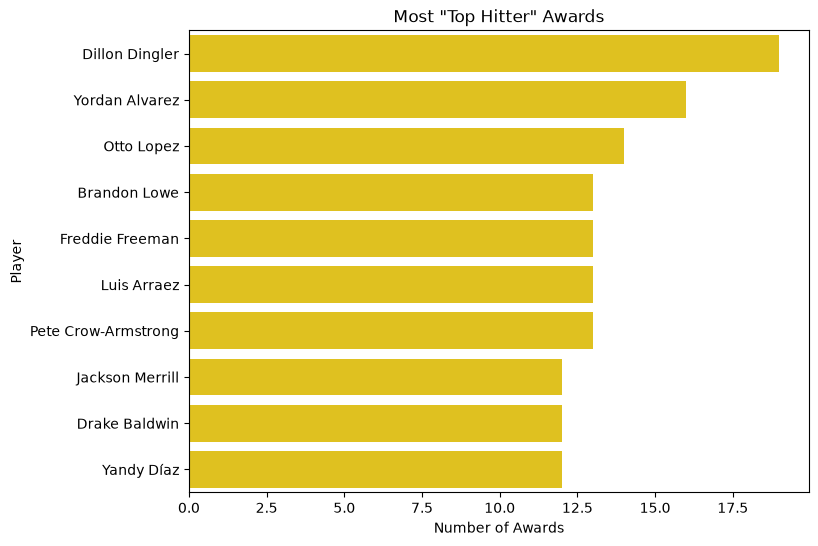

In [44]:
top_hitters=mlb['top_hitter'].value_counts().head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_hitters.values, y=top_hitters.index, color='gold')
plt.title('Most "Top Hitter" Awards')
plt.xlabel('Number of Awards')
plt.ylabel('Player')
plt.show()

Which team produced the most top hitters?

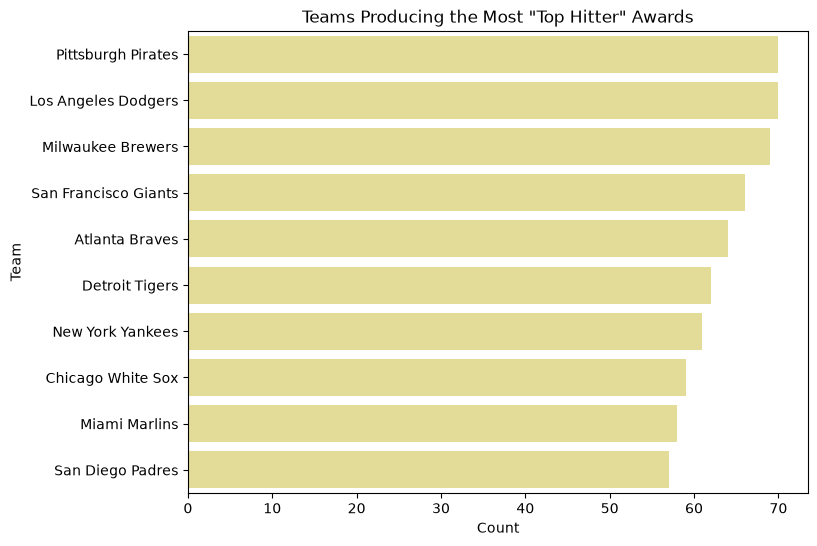

In [45]:
top_hitter_teams=mlb['top_hitter_team'].value_counts().head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_hitter_teams.values, y=top_hitter_teams.index, color='khaki')
plt.title('Teams Producing the Most "Top Hitter" Awards')
plt.xlabel('Count')
plt.ylabel('Team')
plt.show()

Top 10 hitters - Treemap

In [46]:
top10_hitters=mlb['top_hitter'].value_counts().head(10).reset_index()
top10_hitters.columns=['player','awards']

fig=px.treemap(top10_hitters, path=['player'], values='awards', title='Top 10 Hitters by "Top Hitter" Awards')
fig.show()

### Pitchers

Most Winning Pitchers

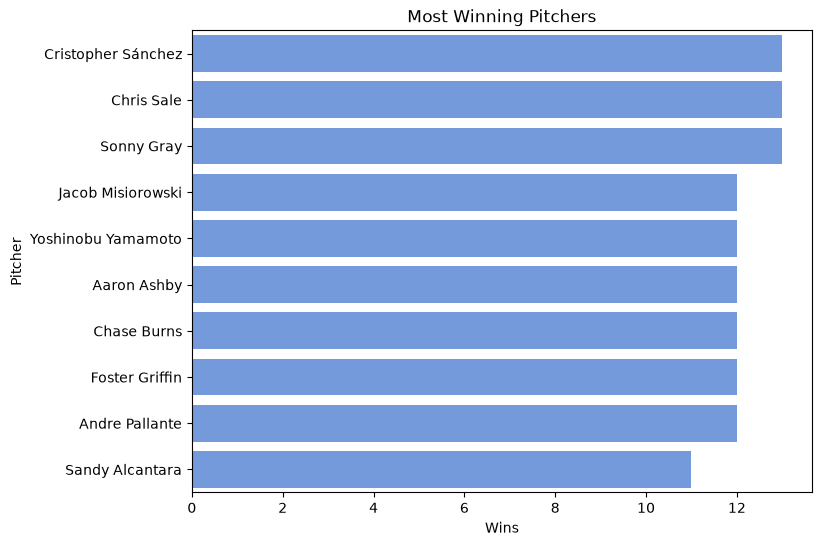

In [47]:
most_wins_pitcher=mlb['winning_pitcher'].value_counts().head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=most_wins_pitcher.values, y=most_wins_pitcher.index, color='cornflowerblue')
plt.title('Most Winning Pitchers')
plt.xlabel('Wins')
plt.ylabel('Pitcher')
plt.show()

Most Saves

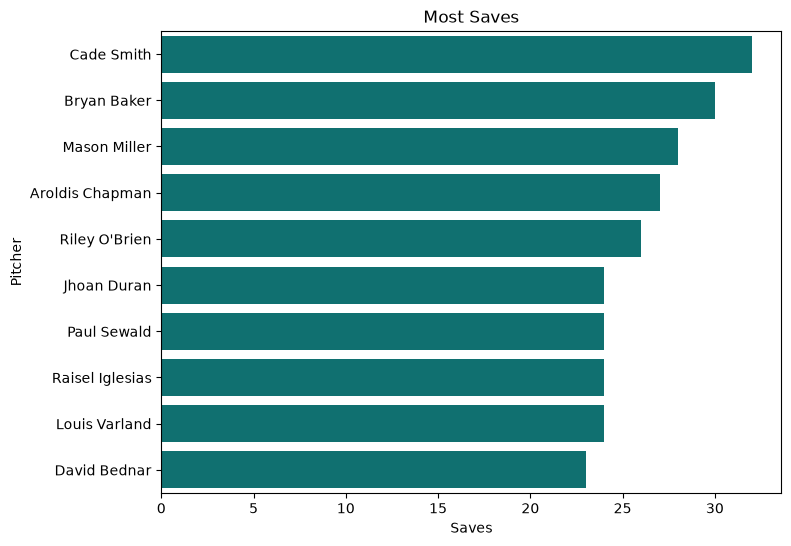

In [48]:
most_saves=mlb['save_pitcher'].value_counts().head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=most_saves.values, y=most_saves.index, color='teal')
plt.title('Most Saves')
plt.xlabel('Saves')
plt.ylabel('Pitcher')
plt.show()

Most 'Top Pitcher' appearances

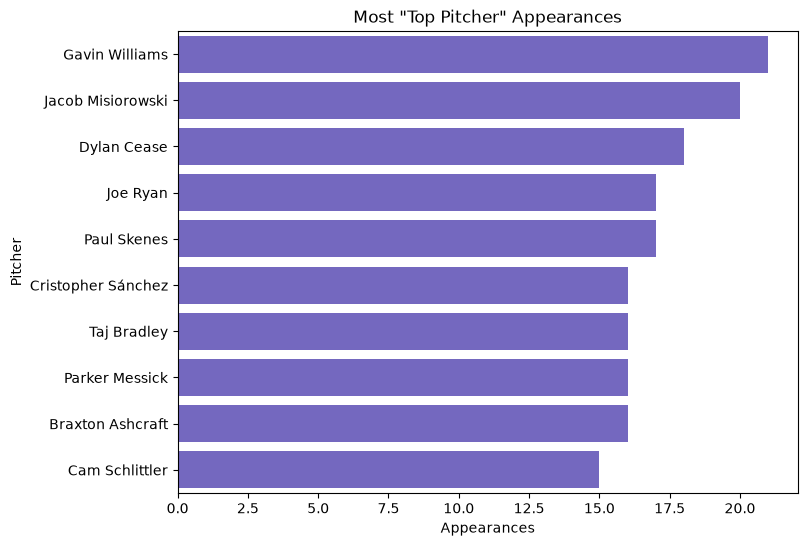

In [49]:
most_top_pitcher=mlb['top_pitcher'].value_counts().head(10)

plt.figure(figsize=(8,6))
sns.barplot(x=most_top_pitcher.values, y=most_top_pitcher.index, color='slateblue')
plt.title('Most "Top Pitcher" Appearances')
plt.xlabel('Appearances')
plt.ylabel('Pitcher')
plt.show()

## Interesting Questions 

1. Which stadium (venue) hosts the highest scoring games?

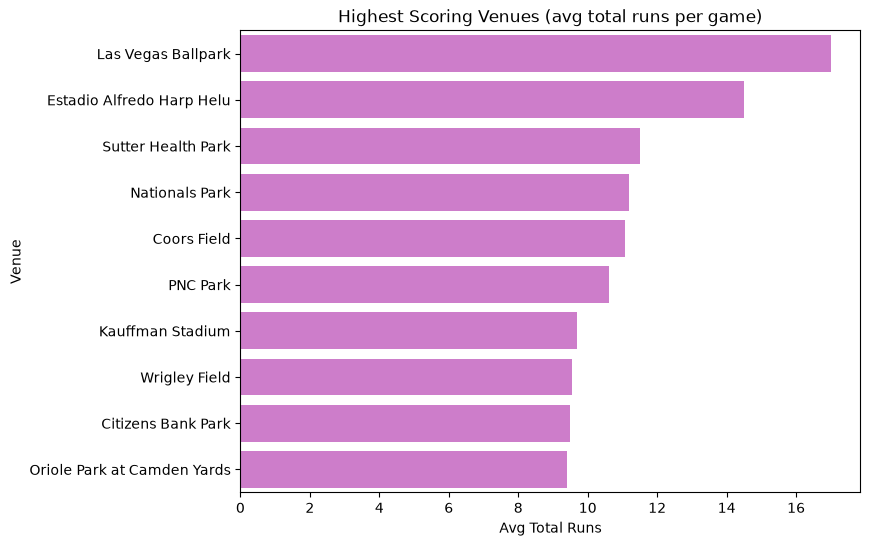

In [51]:
venue_scoring=mlb.groupby('venue')['total_runs'].mean().sort_values(ascending=False).head(10).round(2)

plt.figure(figsize=(8,6))
sns.barplot(x=venue_scoring.values, y=venue_scoring.index, color='orchid')
plt.title('Highest Scoring Venues (avg total runs per game)')
plt.xlabel('Avg Total Runs')
plt.ylabel('Venue')
plt.show()

2. Which venue has the biggest home-field advantage?

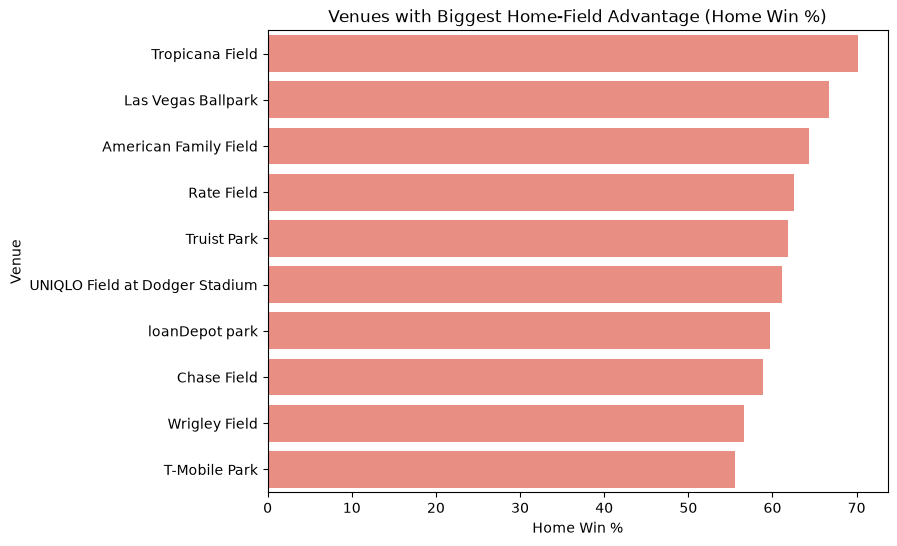

In [52]:
venue_home_adv=mlb.groupby('venue')['home_win'].mean().mul(100).sort_values(ascending=False).head(10).round(2)

plt.figure(figsize=(8,6))
sns.barplot(x=venue_home_adv.values, y=venue_home_adv.index, color='salmon')
plt.title('Venues with Biggest Home-Field Advantage (Home Win %)')
plt.xlabel('Home Win %')
plt.ylabel('Venue')
plt.show()

3. Which teams win by the largest margins? (see 'Team Comparisons' dominant_teams above)

In [53]:
dominant_teams.head(5)

winner
Washington Nationals    4.35
Chicago Cubs            4.27
Los Angeles Dodgers     4.21
San Francisco Giants    4.15
Los Angeles Angels      4.14
Name: margin, dtype: float64

4. Which teams are involved in the closest games? (lowest average margin, win or lose)

In [54]:
home_margin=mlb[['home_team','margin']].rename(columns={'home_team':'team'})
away_margin=mlb[['away_team','margin']].rename(columns={'away_team':'team'})
team_margin=pd.concat([home_margin,away_margin],ignore_index=True)
closest_teams=team_margin.groupby('team')['margin'].mean().sort_values().head(10).round(2)
closest_teams

team
Cleveland Guardians     2.96
St. Louis Cardinals     3.10
Seattle Mariners        3.23
San Diego Padres        3.38
Detroit Tigers          3.41
Baltimore Orioles       3.45
Toronto Blue Jays       3.47
Arizona Diamondbacks    3.47
Kansas City Royals      3.48
Miami Marlins           3.49
Name: margin, dtype: float64

5. Which teams play the highest-scoring games? (avg total runs in games they're involved in)

In [55]:
home_total=mlb[['home_team','total_runs']].rename(columns={'home_team':'team'})
away_total=mlb[['away_team','total_runs']].rename(columns={'away_team':'team'})
team_total_runs=pd.concat([home_total,away_total],ignore_index=True)
highest_scoring_teams=team_total_runs.groupby('team')['total_runs'].mean().sort_values(ascending=False).head(10).round(2)
highest_scoring_teams

team
Washington Nationals    10.64
Colorado Rockies        10.34
Athletics               10.03
Pittsburgh Pirates       9.79
Minnesota Twins          9.67
Houston Astros           9.64
Chicago Cubs             9.51
Baltimore Orioles        9.27
Kansas City Royals       9.16
Los Angeles Angels       9.15
Name: total_runs, dtype: float64

6 & 7. Strongest offense / weakest defense 

In [56]:
print('Strongest offense (top 5):')
print(avg_runs.head(5))
print()
print('Weakest defense - allows the most runs (top 5):')
print(avg_allowed_runs.sort_values(ascending=False).head(5))

Strongest offense (top 5):
team
Washington Nationals    5.423423
Los Angeles Dodgers     5.171171
Chicago Cubs            5.169643
Milwaukee Brewers       5.035714
Pittsburgh Pirates      5.017544
Name: runs, dtype: float64

Weakest defense - allows the most runs (top 5):
team
Athletics               5.654545
Colorado Rockies        5.633929
Washington Nationals    5.216216
Kansas City Royals      4.982143
Minnesota Twins         4.954955
Name: runs_allowed, dtype: float64


8. Which teams perform most consistently? (lowest variance / std dev in runs scored)

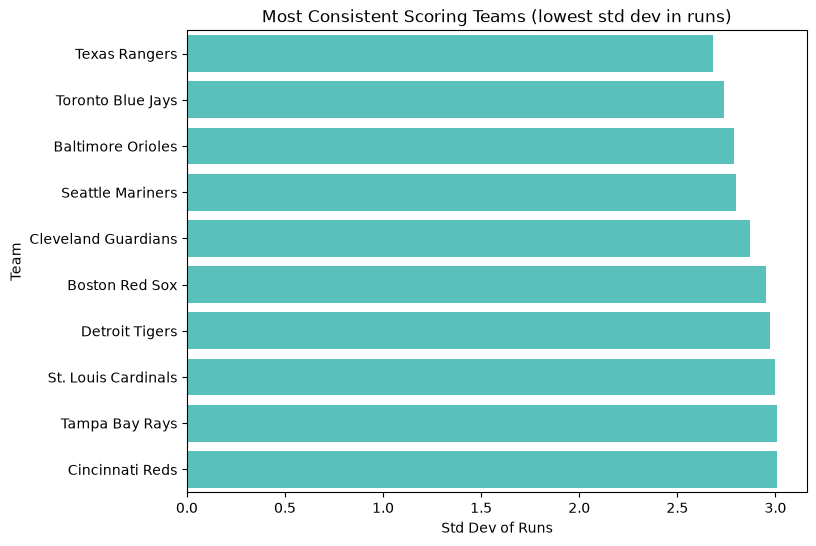

In [57]:
team_consistency=runs.groupby('team')['runs'].std().sort_values().head(10).round(2)

plt.figure(figsize=(8,6))
sns.barplot(x=team_consistency.values, y=team_consistency.index, color='mediumturquoise')
plt.title('Most Consistent Scoring Teams (lowest std dev in runs)')
plt.xlabel('Std Dev of Runs')
plt.ylabel('Team')
plt.show()

9. Which weekday has the highest number of games played?

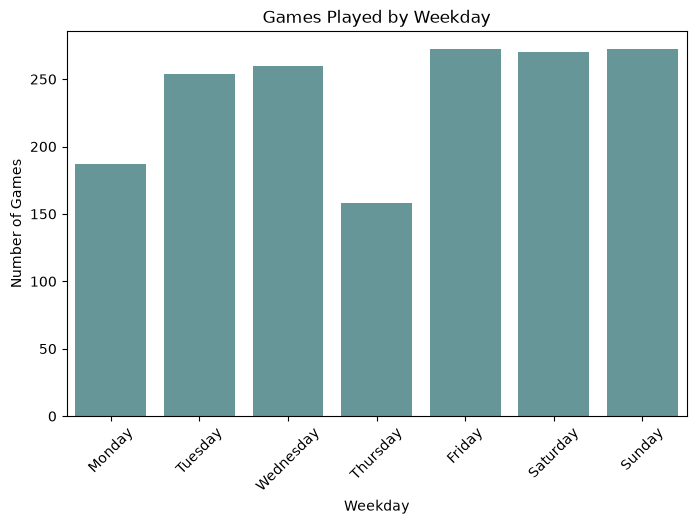

In [58]:
games_by_weekday=mlb['weekday'].value_counts().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.figure(figsize=(8,5))
sns.barplot(x=games_by_weekday.index, y=games_by_weekday.values, color='cadetblue')
plt.title('Games Played by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Number of Games')
plt.xticks(rotation=45)
plt.show()

10. Are weekends higher scoring than weekdays?

Weekday    9.02
Weekend    8.85
Name: total_runs, dtype: float64


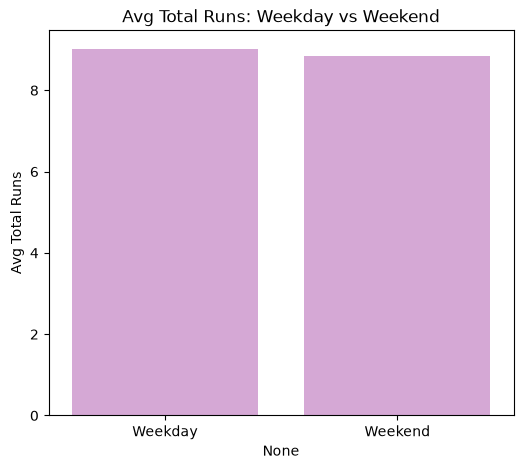

In [59]:
mlb['is_weekend']=mlb['weekday'].isin(['Saturday','Sunday'])
weekend_vs_weekday=mlb.groupby('is_weekend')['total_runs'].mean().round(2)
weekend_vs_weekday.index=['Weekday','Weekend']
print(weekend_vs_weekday)

plt.figure(figsize=(6,5))
sns.barplot(x=weekend_vs_weekday.index, y=weekend_vs_weekday.values, color='plum')
plt.title('Avg Total Runs: Weekday vs Weekend')
plt.ylabel('Avg Total Runs')
plt.show()

## Statistical Analysis

Correlation between home score and away score

Correlation between home_score and away_score: -0.008


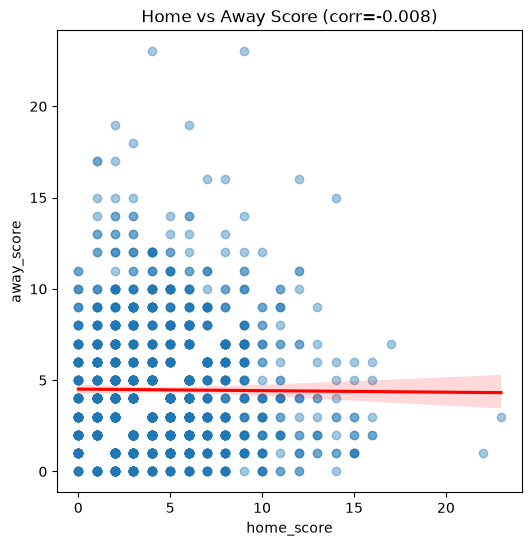

In [60]:
corr_home_away=mlb['home_score'].corr(mlb['away_score']).round(3)
print(f'Correlation between home_score and away_score: {corr_home_away}')

plt.figure(figsize=(6,6))
sns.regplot(data=mlb, x='home_score', y='away_score', scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title(f'Home vs Away Score (corr={corr_home_away})')
plt.show()

Distribution of winning margins

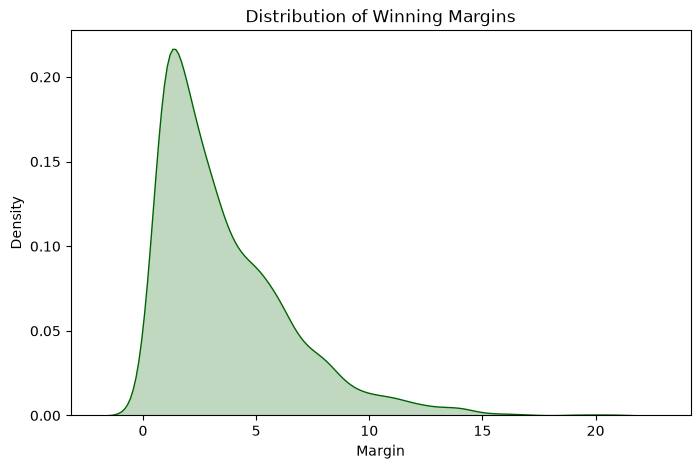

In [61]:
plt.figure(figsize=(8,5))
sns.kdeplot(mlb['margin'], fill=True, color='darkgreen')
plt.title('Distribution of Winning Margins')
plt.xlabel('Margin')
plt.show()

Outlier detection - boxplot of margins by game_type

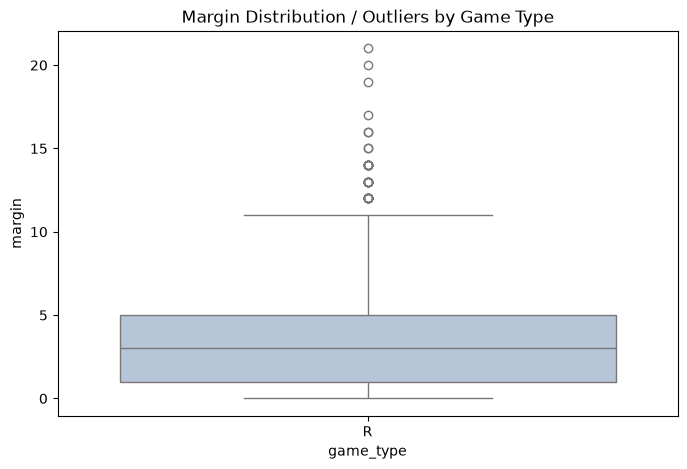

In [62]:
plt.figure(figsize=(8,5))
sns.boxplot(data=mlb, x='game_type', y='margin', color='lightsteelblue')
plt.title('Margin Distribution / Outliers by Game Type')
plt.show()

## Interactive Plotly Dashboard



Win leaderboard & Runs leaderboard (interactive)

In [67]:
win_leaderboard=mlb['winner'].value_counts().reset_index()
win_leaderboard.columns=['team','wins']
fig=px.bar(win_leaderboard, x='wins', y='team', orientation='h', title='Win Leaderboard', color='wins', color_continuous_scale='Blues')
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()

runs_leaderboard=avg_runs.reset_index()
runs_leaderboard.columns=['team','avg_runs']
fig=px.bar(runs_leaderboard, x='avg_runs', y='team', orientation='h', title='Runs Leaderboard (avg runs/game)', color='avg_runs', color_continuous_scale='Oranges')
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()